In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Exploracion de datos

# 1.1 
Se puede decir que este dataset está “sucio” ya que pueden haber datos erróneos o faltantes. Imprima en pantalla un fragmento aleatorio del dataset e indique qué columnas sería útil modificar y de qué manera. Es útil explorar un resumen con los estadísticos básicos y les recordamos que pueden existir valores faltantes (expresados como NaNs).

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
import sys
sys.path.append('../src')
from IPython.display import display
from utils import *
from data_splitting import *
from preprocessing import *
from models import *
from metrics import *


df = pd.read_csv('../data/raw/casas_dev.csv')
n = np.random.randint(10, 20)
df_sample = df.sample(n)
display(df_sample)

,area,area_units,is_house,has_pool,age,price,lat,lon,rooms
756,1313.0,sqft,0,0,4.0,1220.0,40.711074,-74.005307,4.0
545,1227.0,sqft,0,0,12.0,820.0,40.759426,-74.016980,3.0
366,121.0,m2,0,1,14.0,267.0,-34.604537,-58.373459,4.0
626,99.0,m2,1,1,7.0,229.0,-34.605839,-58.403591,3.0
272,732.0,sqft,0,0,3.0,539.0,40.736304,-74.005150,2.0
736,55.0,m2,1,0,NaN,116.0,-34.594890,-58.376562,2.0
356,117.0,m2,1,0,18.0,199.0,-34.617743,-58.423348,4.0
323,980.0,sqft,1,1,15.0,918.0,40.662007,-74.015050,2.0
632,113.0,m2,1,0,NaN,203.0,-34.647057,-58.380696,3.0
275,1410.0,sqft,0,0,5.0,987.0,40.704880,-74.058238,4.0


The columns that would need to be modified are age, rooms, and area. Age and rooms should be modified because both have NaN values, so they should be replaced by the average of the column values. In the case of area, the units should be modified if area_units is sqft so that all areas are in m2. This way, all areas are in the same unit and the exploration can be performed appropriately.

In [5]:
age_mean = df['age'].mean()
age_std = df['age'].std()
rooms_mean = df['rooms'].mean()
rooms_std = df['rooms'].std()

stats = pd.DataFrame({
    "Feature": ["age", "rooms"],
    "Mean": [age_mean, rooms_mean],
    "Standard Deviation": [age_std, rooms_std]
})

display(stats)

seed = 42
handle_missing_values(df, age_mean, age_std, rooms_mean, rooms_std, seed)
df = convert_sqft_to_m2(df)
df.to_csv('../data/processed/casas_dev_processed.csv', index=False)

,Feature,Mean,Standard Deviation
0,age,10.212987,4.773010
1,rooms,2.737923,0.948574


# 1.2

Realice una serie de histogramas y diagramas de dispersión (scatterplots) para mostrar la relación entre las variables. Para esto, es útil el comando pairplot. ¿Qué conclusiones puede extraer a simple vista acerca de las relaciones entre las variables? Se permite la creación de gráficos adicionales que considere relevantes.

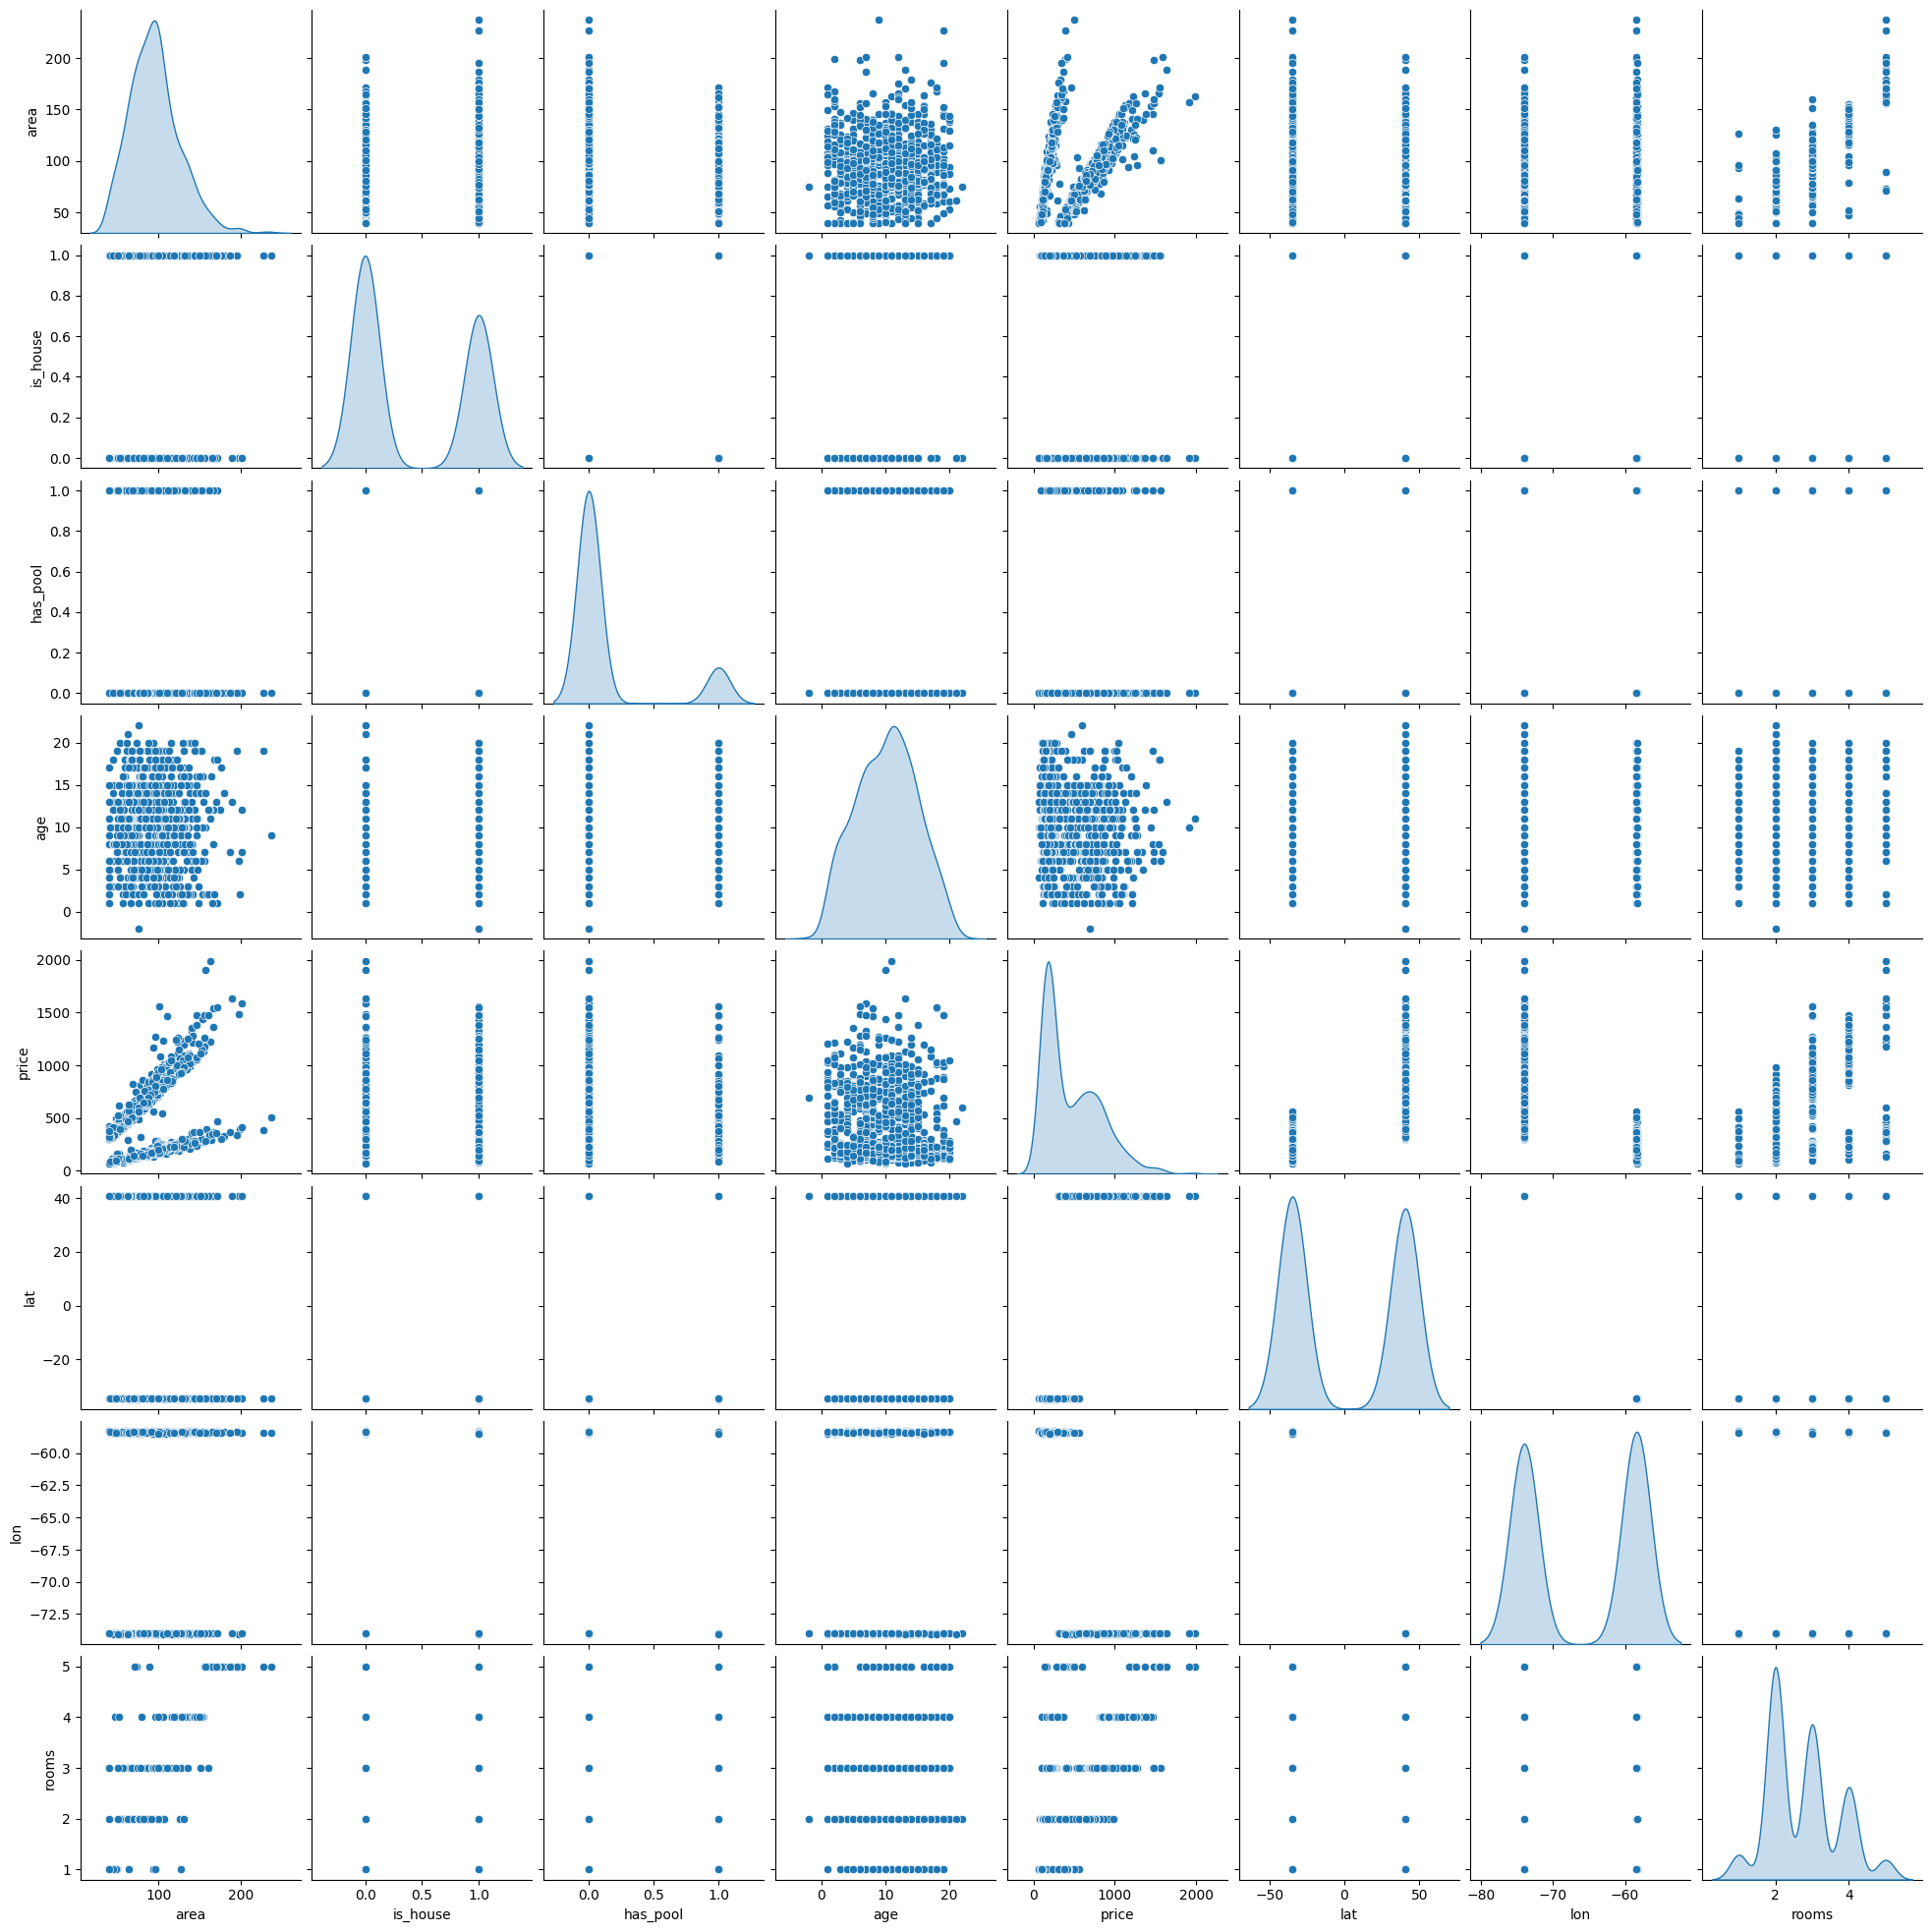

In [120]:
df = pd.read_csv('../data/processed/casas_dev_processed.csv')
sns.pairplot(df, diag_kind="kde")
plt.show()

From these graphs, a positive relationship between area and price can be observed. As the area increases, the price also tends to increase. Furthermore, a separation between houses and non-houses is evident in this relationship, evidenced by the presence of two clusters.

A correlation is also observed between area and number of rooms, as the larger the area, the greater the number of rooms. Similarly, there is a relationship between price and number of rooms, although it is less pronounced than that between area and price, since in general, as price increases, so does the number of rooms.

Regarding binary variables, such as is_house and has_pool, their discrete nature is reflected in the distribution of points in the graphs, where they only take specific values.

On the other hand, some variables, such as rooms, exhibit multimodal distributions, suggesting the existence of different types of housing with different numbers of rooms. Furthermore, the variable price shows a right-skewed distribution, with a concentration of low values ​​and the presence of some extremely high values.

# 1.3
Divida el conjunto de desarrollo casas_dev.csv en un 80% para entrenamiento (train) y un 20% para validación (validation). Estos conjuntos se utilizarán para entrenar y validar los modelos que desarrollarán en las siguientes secciones. Se sugiere normalizar los datos para lograr un mejora el condicionamiento numérico de los algortmos de aprendizaje. 

**RECUERDE** que si normaliza los datos, cuando haga una predicción deberá invertir la normalización para volver a las escalas originales.

In [6]:
df = pd.read_csv('../data/raw/casas_dev.csv')

train_df, validation_df = train_val_split_df(df, val_size=0.2, seed=seed)

train_age_mean = train_df['age'].mean()
train_age_std = train_df['age'].std()
train_rooms_mean = train_df['rooms'].mean()
train_rooms_std = train_df['rooms'].std()

validation_age_mean = validation_df['age'].mean()
validation_age_std = validation_df['age'].std()
validation_rooms_mean = validation_df['rooms'].mean()
validation_rooms_std = validation_df['rooms'].std()

stats = pd.DataFrame({
    "Feature": ["Train age", "Train rooms", "Validation age", "Validation rooms"],
    "Mean": [train_age_mean, train_rooms_mean, validation_age_mean, validation_rooms_mean],
    "Standard Deviation": [train_age_std, train_rooms_std, validation_age_std, validation_rooms_std]
})

display(stats)

handle_missing_values(train_df, train_age_mean, train_age_std, train_rooms_mean, train_rooms_std, seed)
handle_missing_values(validation_df, train_age_mean, train_age_std, train_rooms_mean, train_rooms_std, seed)
train_df = convert_sqft_to_m2(train_df)
validation_df = convert_sqft_to_m2(validation_df)

train_df.to_csv('../data/processed/train_df_processed.csv', index=False)
validation_df.to_csv('../data/processed/validation_df_processed.csv', index=False)

columns_to_not_normalize = ['is_house', 'has_pool', 'price', 'lat', 'lon']
train_mean = train_df.drop(columns=["area_units"] + columns_to_not_normalize).mean()
train_std = train_df.drop(columns=["area_units"] + columns_to_not_normalize).std()

train_df_normalized = normalize_data(train_df, train_mean, train_std, columns_to_not_normalize)
validation_df_normalized = normalize_data(validation_df, train_mean, train_std, columns_to_not_normalize)

print('Train set normalized:\n')
display(train_df_normalized.head())
print('\nValidation set normalized:\n')
display(validation_df_normalized.head())

,Feature,Mean,Standard Deviation
0,Train age,10.176183,4.808926
1,Train rooms,2.731118,0.944879
2,Validation age,10.356688,4.642353
3,Validation rooms,2.765060,0.965581


Train set normalized:



,area,age,rooms,is_house,has_pool,price,lat,lon
70,-0.454237,0.187335,-0.777468,0,0,630.0,40.718433,-74.008699
827,0.171946,-0.654358,0.284727,0,0,772.0,40.707037,-73.998823
231,1.395632,-0.023088,1.346922,0,0,214.0,-34.550223,-58.391268
588,-0.751981,-0.023088,-0.777468,1,1,751.0,40.726223,-74.043929
39,1.957314,1.239451,1.346922,1,0,273.0,-34.563525,-58.347365



Validation set normalized:



,area,age,rooms,is_house,has_pool,price,lat,lon
1,0.239476,-0.233511,0.284727,0,0,759.0,40.712839,-73.967750
4,1.098943,-0.443935,1.346922,0,0,963.0,40.722322,-73.983229
13,0.206188,1.029028,0.284727,1,1,207.0,-34.614459,-58.442886
14,-1.710139,-1.496051,-1.839663,0,0,109.0,-34.598710,-58.375849
20,0.702974,0.187335,1.346922,0,0,854.0,40.735012,-74.030504


# 2. Implementación de Regresión Lineal

# 2.1
Implemente una clase de regresión lineal. El constructor deberá recibir X e y, y se deberá incluir como métodos de entrenamiento de la clase: entrenamiento mediante la pseudo-inversa y entrenamiento mediante descenso por gradiente. En ambos casos se debe almacenar como atributo self.coef los coeficientes (pesos) resultantes de la regresión.

**NOTA**: Asegúrese de que haya un método que permita imprimir los coeficientes con los nombres de sus respectivas variables de forma prolija.

In [7]:
features = ['area', 'is_house', 'has_pool', 'age', 'lat','lon', 'rooms']
target = 'price'

X_train, y_train = prepare_data(train_df_normalized, features, target)
X_validation, y_validation = prepare_data(validation_df_normalized, features, target)

model_pseudo = LinearRegression(X_train, y_train)
model_pseudo.train_pseudo_inverse()
print(f"\nPseudoinverse coefficients: \n")
model_pseudo.print_coef(features)

model_gradient = LinearRegression(X_train, y_train)
model_gradient.train_gradient_descent()
print(f"\nGradient descent coefficients: \n")
model_gradient.print_coef(features)


Pseudoinverse coefficients: 


Model coefficients:
------------------------------
area                 | 11212.24283
is_house             | 143.60374
has_pool             | 77.04537
age                  | 46.56399
lat                  | -10.21084
lon                  | 42.58819
rooms                | 164.78985
------------------------------

Gradient descent coefficients: 


Model coefficients:
------------------------------
area                 | 0.08302
is_house             | 71.51902
has_pool             | 11.96108
age                  | 5.73614
lat                  | 0.41540
lon                  | 6.49003
rooms                | -6.76268
------------------------------


# 2.2
Implemente la función de pérdida utilizando el Error Cuadrático Medio (ECM).

In [8]:
print(f'Pseudoinverse performance:')
evaluate_model_performance(X_train, y_train, model_pseudo)
evaluate_model_performance(X_validation, y_validation, model_pseudo, set='Validation')
print(f'\nGradient descent performance:')
evaluate_model_performance(X_train, y_train, model_gradient)
evaluate_model_performance(X_validation, y_validation, model_gradient, set='Validation')

Pseudoinverse performance:


,MSE,RMSE,MAE,R²
Train,15066.35,122.75,88.52,0.87


,MSE,RMSE,MAE,R²
Validation,16300.88,127.67,87.96,0.87



Gradient descent performance:


,MSE,RMSE,MAE,R²
Train,17386.83,131.86,93.26,0.85


,MSE,RMSE,MAE,R²
Validation,17990.04,134.13,92.46,0.86


# 2.3
Verifique que su implementación de la regresión lineal funcione correctamente tanto para cuando se tiene una característica como para múltiples características.

Pseudoinverse 1: 


Model coefficients:
------------------------------
area                 | 467.68333
------------------------------


,MSE,RMSE,MAE,R²
Train,104604.93,323.43,296.13,0.12


,MSE,RMSE,MAE,R²
Validation,100503.14,317.02,288.93,0.19


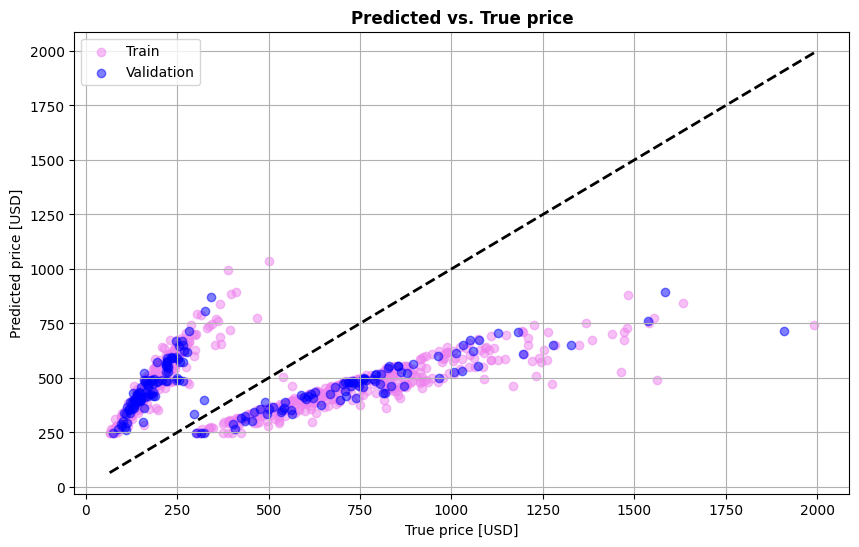


Gradient descent 1: 


Model coefficients:
------------------------------
area                 | 295.64085
------------------------------


,MSE,RMSE,MAE,R²
Train,136193.88,369.04,289.66,-0.14


,MSE,RMSE,MAE,R²
Validation,132948.72,364.62,282.34,-0.07


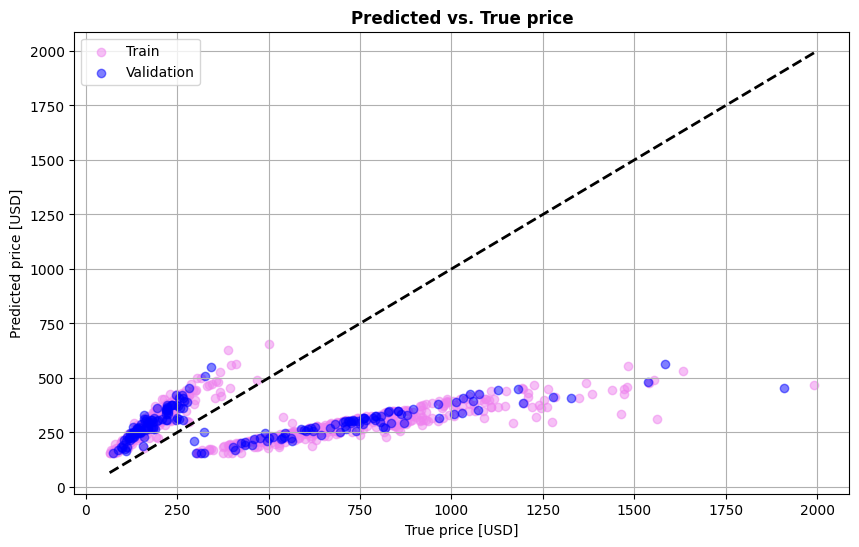


Pseudoinverse 2: 


Model coefficients:
------------------------------
area                 | 11212.24283
is_house             | 143.60374
has_pool             | 77.04537
age                  | 46.56399
lat                  | -10.21084
lon                  | 42.58819
rooms                | 164.78985
------------------------------


,MSE,RMSE,MAE,R²
Train,15066.35,122.75,88.52,0.87


,MSE,RMSE,MAE,R²
Validation,16300.88,127.67,87.96,0.87


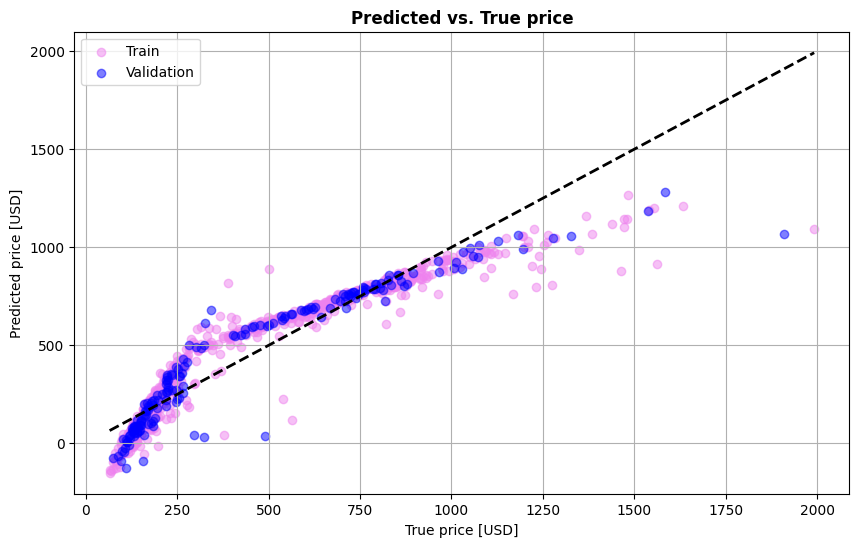


Gradient descent 2: 


Model coefficients:
------------------------------
area                 | 0.08302
is_house             | 71.51902
has_pool             | 11.96108
age                  | 5.73614
lat                  | 0.41540
lon                  | 6.49003
rooms                | -6.76268
------------------------------


,MSE,RMSE,MAE,R²
Train,17386.83,131.86,93.26,0.85


,MSE,RMSE,MAE,R²
Validation,17990.04,134.13,92.46,0.86


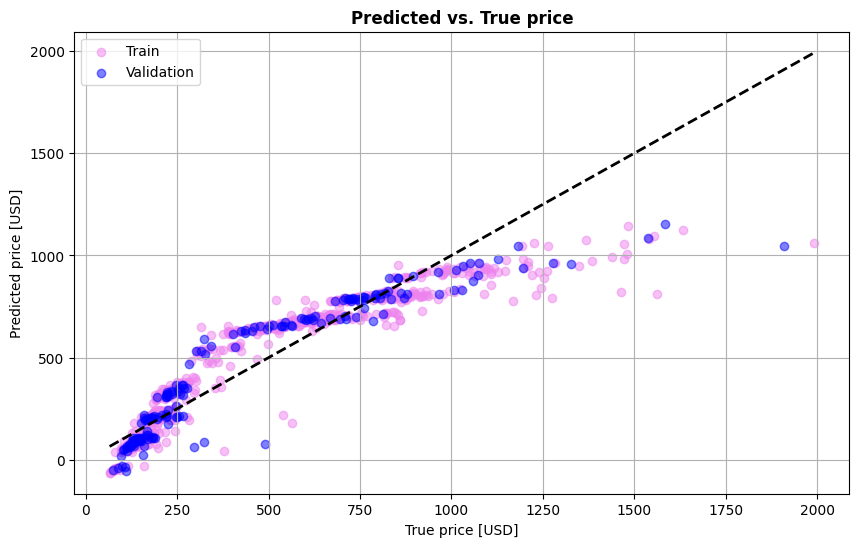

In [9]:
X_train1, y_train1 = prepare_data(train_df_normalized, [features[0]], target)
X_validation1, y_validation1 = prepare_data(validation_df_normalized, [features[0]], target)

# 1 ( one feature )

model1_1 = LinearRegression(X_train1, y_train1)
model1_1.train_pseudo_inverse()
print(f"Pseudoinverse 1: \n")
model1_1.print_coef([features[0]])
evaluate_model_performance(X_train1, y_train1, model1_1)
evaluate_model_performance(X_validation1, y_validation1, model1_1, set='Validation')
model1_1.plot_model_performance(X_train1, y_train1, X_validation1, y_validation1, target)

model1_2 = LinearRegression(X_train1, y_train1)
model1_2.train_gradient_descent()
print(f"\nGradient descent 1: \n")
model1_2.print_coef([features[0]])
evaluate_model_performance(X_train1, y_train1, model1_2)
evaluate_model_performance(X_validation1, y_validation1, model1_2, set='Validation')
model1_2.plot_model_performance(X_train1, y_train1, X_validation1, y_validation1, target)

# 2 ( multiple features )

model_pseudo.train_pseudo_inverse()
print(f"\nPseudoinverse 2: \n")
model_pseudo.print_coef(features)
evaluate_model_performance(X_train, y_train, model_pseudo)
evaluate_model_performance(X_validation, y_validation, model_pseudo, set='Validation')
model_pseudo.plot_model_performance(X_train, y_train, X_validation, y_validation, target)

model2_2 = LinearRegression(X_train, y_train)
model2_2.train_gradient_descent()
print(f"\nGradient descent 2: \n")
model2_2.print_coef(features)
evaluate_model_performance(X_train, y_train, model2_2)
evaluate_model_performance(X_validation, y_validation, model2_2, set='Validation')
model2_2.plot_model_performance(X_train, y_train, X_validation, y_validation, target)

# 3 Aplicación de Modelos de Regresión

# 3.1
Realice una regresión lineal simple (con una sola característica) para predecir el precio de una propiedad utilizando como variable explicativa solo el area.

In [10]:
print(f"Pseudoinverse: \n")

y_pred_train1 = model1_1.predict(X_train1)
y_pred_validation1 = model1_1.predict(X_validation1)
evaluate_model_performance(X_train1, y_train1, model1_1)
evaluate_model_performance(X_validation1, y_validation1, model1_1, set='Validation')

prices = pd.DataFrame({
    "Predicted price from training set": [f"${y_pred_train1[0]:.2f}"],
    "Predicted price from validation set": [f"${y_pred_validation1[0]:.2f}"],
    "Real price": [f"${y_validation1[0]:.2f}"],
})

display(prices)

Pseudoinverse: 



,MSE,RMSE,MAE,R²
Train,104604.93,323.43,296.13,0.12


,MSE,RMSE,MAE,R²
Validation,100503.14,317.02,288.93,0.19


,Predicted price from training set,Predicted price from validation set,Real price
0,$412.63,$496.71,$759.00


# 3.2
Desarrolle un modelo de regresión lineal que prediga el precio en función de las caraceterísticas que considere relevantes. Utilizando el modelo entrenado, prediga el precio de vivienda_Amanda.csv.

In [11]:
columns_to_not_normalize_amanda = ['is_house', 'has_pool', 'lat', 'lon']
vivienda_amanda = pd.read_csv('../data/raw/vivienda_Amanda.csv')
vivienda_amanda = convert_sqft_to_m2(vivienda_amanda)
vivienda_amanda_normalized = normalize_data(vivienda_amanda, train_mean, train_std, columns_to_not_normalize_amanda)
X_amanda = prepare_data(vivienda_amanda_normalized, features, target, predict=1)
y_amanda_predic = model_pseudo.predict(X_amanda)
print(f"\nAmanda's house price: ${y_amanda_predic[0]:.2f}")


Amanda's house price: $792.01


# 3.3
En el dataset, ¿cuál es el valor promedio por metro cuadrado de una casa?

In [12]:
print(f"Average value per square meter of a house: ${average_price_per_m2(train_df):.2f}")

Average value per square meter of a house: $3.60


# 3.4
Benito está evaluando la posibilidad de construir una pileta. ¿Cómo afectaría la construcción de una pileta al precio de su propiedad? Explique cómo llegó a este resultado.

In [13]:
if "has_pool" in train_df.columns:
    idx_pool = list(train_df.columns).index("has_pool")
else:
    raise ValueError("The variable 'has_pool' was not found in the dataset.")

pool_coef = model_pseudo.coef[idx_pool-1]
if pool_coef > 0:
    print(f"Slope of the coefficient associated with the pool: {pool_coef:.4f}")
    print('Benito should build a pool.')
    print(f"Estimated impact on the price of a pool: ${pool_coef:.2f}")
elif pool_coef < 0:
    print(f"Slope of the coefficient associated with the pool: {pool_coef:.4f}")
    print('It is not convenient for Benito to build a pool.')
    print(f"Estimated impact on the price of a pool: ${pool_coef:.2f}")
else:
    print("The pool has no impact on the price of the house")


Slope of the coefficient associated with the pool: 77.0454
Benito should build a pool.
Estimated impact on the price of a pool: $77.05


This result was obtained by analyzing the **'has_pool'** column and its coefficient in the regression model. The slope associated with this variable, called **pool_coef**, represents the impact that the presence of a pool has on the property price.

In linear models, each coefficient represents the expected change in the target variable (**price**) for a one-unit increase in the corresponding variable, keeping all others constant.

If **pool_coef** is positive, it means that properties with a pool tend to have a higher price compared to those without. This suggests that the market values ​​the presence of a pool, reflected in an increase in price.

On the other hand, if **pool_coef** is negative, it indicates that the presence of a pool reduces the property's value. This could be due to lower demand for properties with pools in certain areas.

Analyzing this coefficient is relevant in the context of the regression model, as it allows for interpreting the impact of specific features on property prices and, consequently, optimizing valuation and predicting strategies in the real estate market.

# 4. Feature Engineering

# 4.1
Construya un conjunto de características derivadas a partir de las originales, que le parezca relevante para predecir el precio de una propiedad, utilizando técnicas de Feature Engineering.


Evaluating model performance before feature engineering



,MSE,RMSE,MAE,R²
Train,15066.35,122.75,88.52,0.87


,MSE,RMSE,MAE,R²
Validation,16300.88,127.67,87.96,0.87


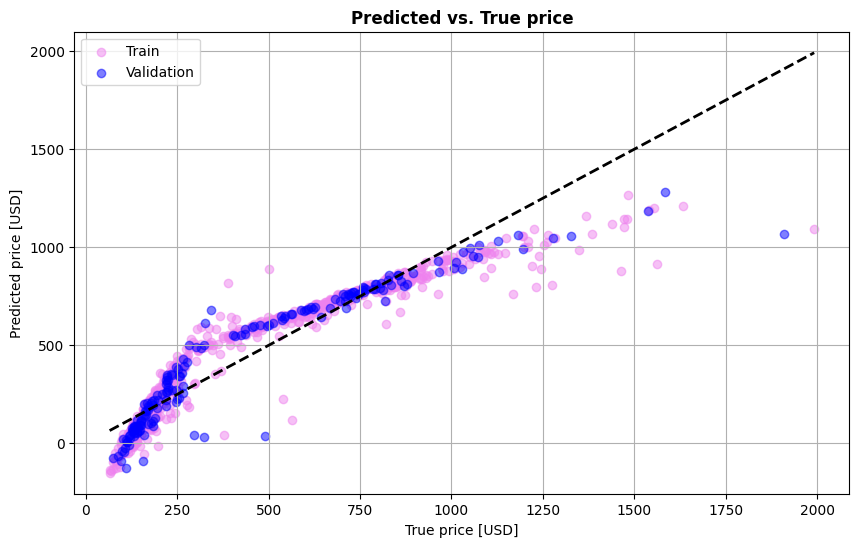

Evaluation of the features for the train set:


**Correlations of rooms_density with other variables:**



,Variable,Correlation
0,rooms,0.351307
1,area,0.099230
2,lon,0.075404
3,lat,0.075382
4,is_house,0.029578
5,price,0.013458
6,age,0.012135
7,has_pool,0.010532



🚨 It is not advisable to use the feature: **price_density** due to high correlation with other variables.


**Correlations of log_price with other variables:**



,Variable,Correlation
0,price,0.948674
1,lon,0.892319
2,lat,0.892224
3,is_house,0.371848
4,area,0.316360
5,rooms,0.307906
6,age,0.197213
7,has_pool,0.083017



**Correlations of log_area with other variables:**



...


**Correlations of age_group with other variables:**



,Variable,Correlation
0,age,0.825866
1,is_house,0.482068
2,rooms,0.156813
3,area,0.148297
4,lon,0.146665
5,lat,0.146465
6,has_pool,0.051485
7,price,0.039455



Evaluating model performance after feature engineering



,MSE,RMSE,MAE,R²
Train,4728.73,68.77,36.10,0.96


,MSE,RMSE,MAE,R²
Validation,4797.52,69.26,34.56,0.96


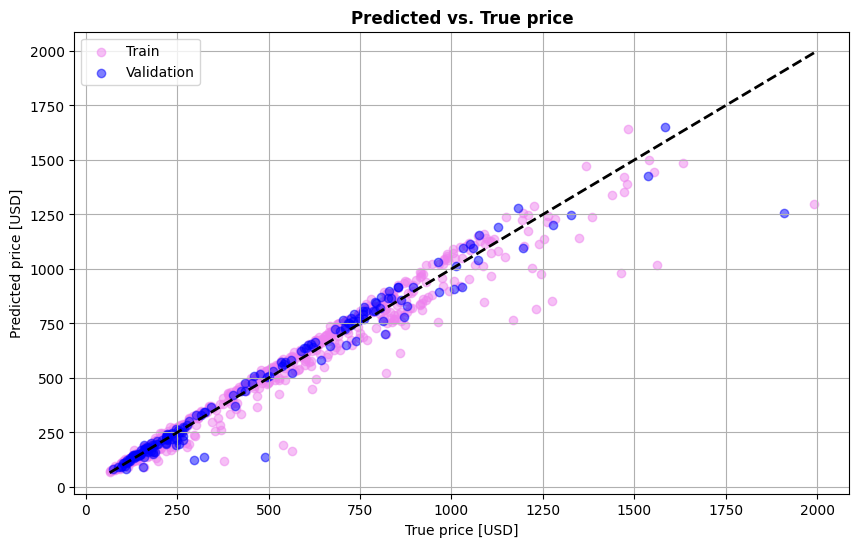

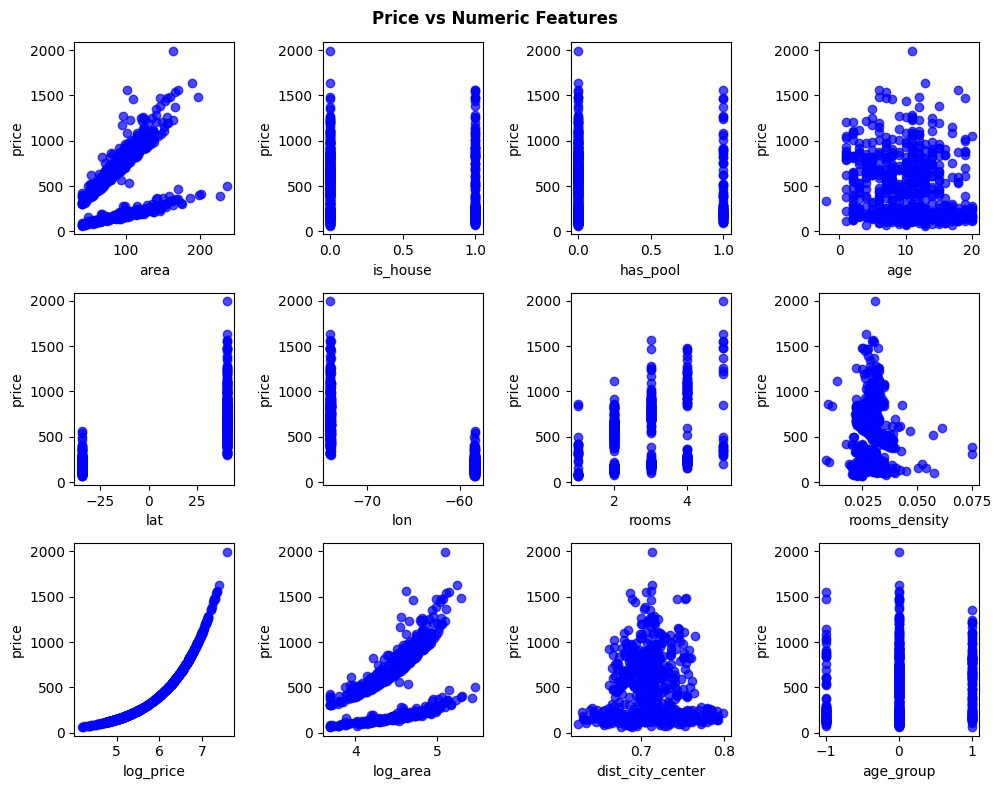

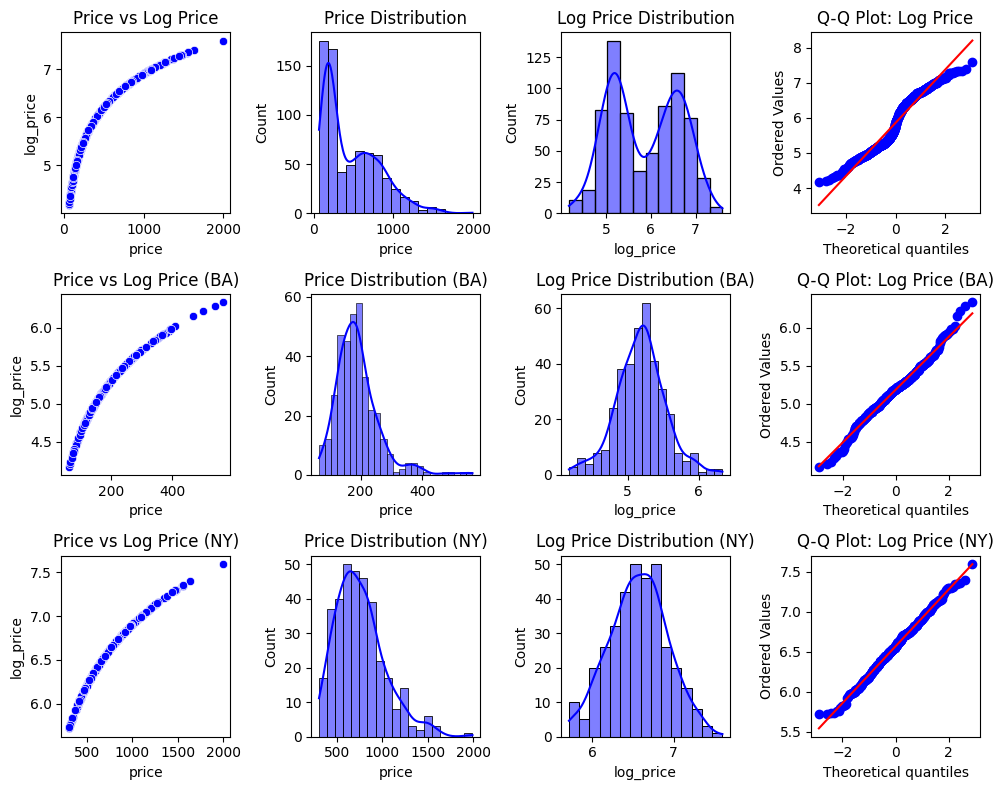

In [14]:
print(f"\nEvaluating model performance before feature engineering\n")
evaluate_model_performance(X_train, y_train, model_pseudo)
evaluate_model_performance(X_validation, y_validation, model_pseudo, set='Validation')
model_pseudo.plot_model_performance(X_train, y_train, X_validation, y_validation, target)

print('Evaluation of the features for the train set:\n')
train_df_Fe = train_df.copy()
train_df_Fe = apply_feature(train_df_Fe, 'rooms_density', dependence(train_df, 'rooms_density', rooms_density), rooms_density)
train_df_Fe = apply_feature(train_df_Fe, 'price_density', dependence(train_df, 'price_density', price_density), price_density)
train_df_Fe = apply_feature(train_df_Fe, 'log_price', dependence(train_df, 'log_price', log_price), log_price)
train_df_Fe = apply_feature(train_df_Fe, 'log_area', dependence(train_df, 'log_area', log_area), log_area)
train_df_Fe = apply_feature(train_df_Fe, 'dist_city_center', dependence(train_df, 'dist_city_center', dist_city_center), dist_city_center)
train_df_Fe = apply_feature(train_df_Fe, 'age_group', dependence(train_df, 'age_group', apply_age_group), apply_age_group)

print('Evaluation of the features for the validation set:\n')
validation_df_Fe = validation_df.copy()
validation_df_Fe = apply_feature(validation_df_Fe, 'rooms_density', dependence(validation_df, 'rooms_density', rooms_density), rooms_density)
validation_df_Fe = apply_feature(validation_df_Fe, 'price_density', dependence(validation_df, 'price_density', price_density), price_density)
validation_df_Fe = apply_feature(validation_df_Fe, 'log_price', dependence(validation_df, 'log_price', log_price), log_price)
validation_df_Fe = apply_feature(validation_df_Fe, 'log_area', dependence(validation_df, 'log_area', log_area), log_area)
validation_df_Fe = apply_feature(validation_df_Fe, 'dist_city_center', dependence(validation_df, 'dist_city_center', dist_city_center), dist_city_center)
validation_df_Fe = apply_feature(validation_df_Fe, 'age_group', dependence(validation_df, 'age_group', apply_age_group), apply_age_group)

train_df_Fe.to_csv('../data/processed/train_dev_feature_engineering.csv', index=False)
validation_df_Fe.to_csv('../data/processed/validation_dev_feature_engineering.csv', index=False)

columns_to_not_normalize_Fe = ['is_house', 'has_pool', 'price', 'log_price', 'lat', 'lon']
train_mean_Fe = train_df_Fe.drop(columns=["area_units"] + columns_to_not_normalize_Fe).mean()
train_std_Fe = train_df_Fe.drop(columns=["area_units"] + columns_to_not_normalize_Fe).std()

train_df_normalized_Fe = normalize_data(train_df_Fe, train_mean_Fe, train_std_Fe, columns_to_not_normalize_Fe)
validation_df_normalized_Fe = normalize_data(validation_df_Fe, train_mean_Fe, train_std_Fe, columns_to_not_normalize_Fe)

features_Fe = ['area', 'is_house', 'has_pool', 'age', 'lat','lon', 'rooms', 'rooms_density', 'log_area', 'dist_city_center', 'age_group']
target_log = 'log_price'  # new target

X_train_Fe, y_train_Fe = prepare_data(train_df_normalized_Fe, features_Fe, target_log)
X_validation_Fe, y_validation_Fe = prepare_data(validation_df_normalized_Fe, features_Fe, target_log)

model_Fe = LinearRegression(X_train_Fe, y_train_Fe)
model_Fe.train_pseudo_inverse()

print(f"\nEvaluating model performance after feature engineering\n")
evaluate_model_performance(X_train_Fe, y_train_Fe, model_Fe, target_modified=1)
evaluate_model_performance(X_validation_Fe, y_validation_Fe, model_Fe, set='Validation', target_modified=1)
model_Fe.plot_model_performance(X_train_Fe, y_train_Fe, X_validation_Fe, y_validation_Fe, target_log)


# graph of how each feature relates to price
numeric_features = train_df_Fe.select_dtypes(include='number').drop(columns=['price']).columns
n_features = len(numeric_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))
f, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 8))
axs = axs.flatten()

for feature, ax in zip(numeric_features, axs):
    if feature != 'price':
        ax.scatter(train_df_Fe[feature], train_df_Fe['price'], color='blue', alpha=0.7)
        ax.set_xlabel(feature)
        ax.set_ylabel('price')
plt.suptitle('Price vs Numeric Features', weight='bold')
plt.tight_layout()
plt.show()

df_copy_BA = train_df_Fe[(train_df_Fe['lon'] >= -60) & (train_df_Fe['lon'] <= -50)]
df_copy_NY = train_df_Fe[(train_df_Fe['lon'] >= -80) & (train_df_Fe['lon'] <= -65)]

fig, axs = plt.subplots(3, 4, figsize=(10, 8))
axs = axs.flatten()

sns.scatterplot(data=train_df_Fe, x='price', y='log_price', color='blue', ax=axs[0])
axs[0].set_title("Price vs Log Price")

sns.histplot(train_df_Fe['price'], kde=True, ax=axs[1], color='blue')
axs[1].set_title("Price Distribution")

sns.histplot(train_df_Fe['log_price'], kde=True, ax=axs[2], color='blue')
axs[2].set_title("Log Price Distribution")

st.probplot(train_df_Fe['log_price'], plot=axs[3])
axs[3].set_title("Q-Q Plot: Log Price")

sns.scatterplot(data=df_copy_BA, x='price', y='log_price', color='blue', ax=axs[4])
axs[4].set_title("Price vs Log Price (BA)")

sns.histplot(df_copy_BA['price'], kde=True, ax=axs[5], color='blue')
axs[5].set_title("Price Distribution (BA)")

sns.histplot(df_copy_BA['log_price'], kde=True, ax=axs[6], color='blue')
axs[6].set_title("Log Price Distribution (BA)")

st.probplot(df_copy_BA['log_price'], plot=axs[7])
axs[7].set_title("Q-Q Plot: Log Price (BA)")

sns.scatterplot(data=df_copy_NY, x='price', y='log_price', color='blue', ax=axs[8])
axs[8].set_title("Price vs Log Price (NY)")

sns.histplot(df_copy_NY['price'], kde=True, ax=axs[9], color='blue')
axs[9].set_title("Price Distribution (NY)")

sns.histplot(df_copy_NY['log_price'], kde=True, ax=axs[10], color='blue')
axs[10].set_title("Log Price Distribution (NY)")

st.probplot(df_copy_NY['log_price'], plot=axs[11])
axs[11].set_title("Q-Q Plot: Log Price (NY)")

plt.tight_layout()
plt.show()

As a result of the feature engineering process, the following new features were created: **'age_group'**, **'dist_city_center'**, **'log_area'** and **'rooms_density'**. These characteristics were obtained using the original variables—area, age, latitude, longitude, or number of rooms—with the goal of generating more informative predictors for estimating property prices.

Additionally, an analysis of the price distribution revealed the presence of two clusters, likely corresponding to two distinct neighborhoods in the dataset. To better understand the relationship between price and neighborhood, the dataset was divided accordingly. Upon further examination, it was observed that each neighborhood exhibits a different price distribution, which aligns with the presence of different types of properties in each area. In both cases, the price follows a **log-normal distribution**.

Given this insight, it is more appropriate to transform the price variable to a logarithmic scale. This transformation enhances prediction accuracy, as most machine learning algorithms perform best when the target variable follows a normal distribution. A normally distributed target helps reduce prediction bias and improves numerical stability.

# 4.2
Realice una regresión lineal como en 3.2, incorporando las características que desarrolló en el punto 4.1.

In [ ]:
vivienda_amanda_Fe = vivienda_amanda.copy()
vivienda_amanda_Fe['rooms_density'] = rooms_density(vivienda_amanda)
vivienda_amanda_Fe['log_area'] = log_area(vivienda_amanda)
vivienda_amanda_Fe['dist_city_center'] = dist_city_center(vivienda_amanda)
vivienda_amanda_Fe['age_group'] = apply_age_group(vivienda_amanda)

vivienda_amanda_normalized_Fe = normalize_data(vivienda_amanda_Fe, train_mean_Fe, train_std_Fe, columns_to_not_normalize_amanda)
X_amanda_Fe = prepare_data(vivienda_amanda_normalized_Fe, features_Fe, target_log, predict=1)
y_amanda_predic_Fe = model_Fe.predict(X_amanda_Fe)
print(f"\nAmanda's house price: ${np.exp( y_amanda_predic_Fe[0] ):.2f}")

evaluate_model_performance(X_train_Fe, y_train_Fe, model_Fe, target_modified=1)
evaluate_model_performance(X_validation_Fe, y_validation_Fe, model_Fe, set='Validation', target_modified=1)
model_Fe.print_coef(features_Fe)


Amanda's house price: $805.79


,MSE,RMSE,MAE,R²
Train,4728.73,68.77,36.10,0.96


,MSE,RMSE,MAE,R²
Validation,4797.52,69.26,34.56,0.96



Model coefficients:
------------------------------
area                 | 7.77967
is_house             | 0.01973
has_pool             | 0.10454
age                  | 0.11601
lat                  | -0.03166
lon                  | 0.02628
rooms                | 0.03089
rooms_density        | 0.00912
log_area             | 0.00376
dist_city_center     | 0.29614
age_group            | 0.00381
------------------------------


# 4.3
Repita el proceso del ítem anterior generando 300 nuevos features como potencias de los features anteriores (por ejemplo: [(x_1)^2,(x_2)^5,...,(x_n)^12 ]).

In [ ]:
np.random.seed(42)

selected_combinations = generate_feature_combinations(train_df_Fe, features=features_Fe)
train_df_300, features_300 = generate_features(train_df_Fe, selected_combinations)
validation_df_300, _ = generate_features(validation_df_Fe, selected_combinations)

train_mean_300 = train_df_300.drop(columns=["area_units"] + columns_to_not_normalize_Fe).mean()
train_std_300 = train_df_300.drop(columns=["area_units"] + columns_to_not_normalize_Fe).std()

train_df_norm_300 = normalize_data(train_df_300, train_mean_300, train_std_300, columns_to_not_normalize_Fe)
X_train_300, y_train_300 = prepare_data(train_df_norm_300, features_300, target_log)
validation_df_norm_300 = normalize_data(validation_df_300, train_mean_300, train_std_300, columns_to_not_normalize_Fe)
X_validation_300, y_validation_300 = prepare_data(validation_df_norm_300, features_300, target_log)

model_300 = LinearRegression(X_train_300, y_train_300)
model_300.train_pseudo_inverse()

vivienda_amanda_300,_ = generate_features(vivienda_amanda_Fe, selected_combinations)
vivienda_amanda_normalized_300 = normalize_data(vivienda_amanda_300, train_mean_300, train_std_300, columns_to_not_normalize_amanda)
X_amanda_300 = prepare_data(vivienda_amanda_normalized_300, features_300, target_log, predict=1)
y_amanda_predic_300 = model_300.predict(X_amanda_300)
print(f"\nAmanda's house price: ${np.exp( y_amanda_predic_300[0] ):.2f}")

evaluate_model_performance(X_train_300, y_train_300, model_300, target_modified=1)
evaluate_model_performance(X_validation_300, y_validation_300, model_300, set='Validation', target_modified=1)


Amanda's house price: $780.01


,MSE,RMSE,MAE,R²
Train,3545.05,59.54,29.66,0.97


,MSE,RMSE,MAE,R²
Validation,4121.44,64.20,30.65,0.97


# 4.4
¿Qué resultados esperaba obtener con estos experimentos?

Based on these experiments, an improvement in property price prediction was expected, reflected in improved evaluation metrics. Initially, by adding new features, the model receives more information and becomes more expressive, which should translate into a significant improvement in its predictive capacity.

Furthermore, by raising the 300 features generated through feature engineering to different powers, the model is able to capture nonlinear relationships between variables. This allows for greater flexibility and improved generalization capabilities compared to a model based solely on the original features derived from feature engineering.

# 5. Regularización

# 5.1
Modifique la clase de Regresión Lineal para que pueda recibir como parámetros dos coeficientes de regularización L2 y L1, que por defecto serán 0.

The LinearRegression class was modified to include two regularization coefficients, **L1** (Lasso) and **L2** (Ridge), which are set to zero by default. These coefficients help control model complexity and mitigate overfitting by penalizing the regression coefficients. **L2** regularization (Ridge) penalizes large coefficient values, while **L1** regularization (Lasso) penalizes the absolute values of the coefficients, promoting sparsity. Additionally, new gradient descent and pseudoinverse training methods were created that incorporate these regularization terms.

# 5.2
Entrene un modelo de regresión lineal con regularización L2 (a veces llamado “Ridge regression”) utilizando como características las mismas que en el punto 4.2 y grafique el valor de los parametros w∗ en función del coeficiente de penalización λ.

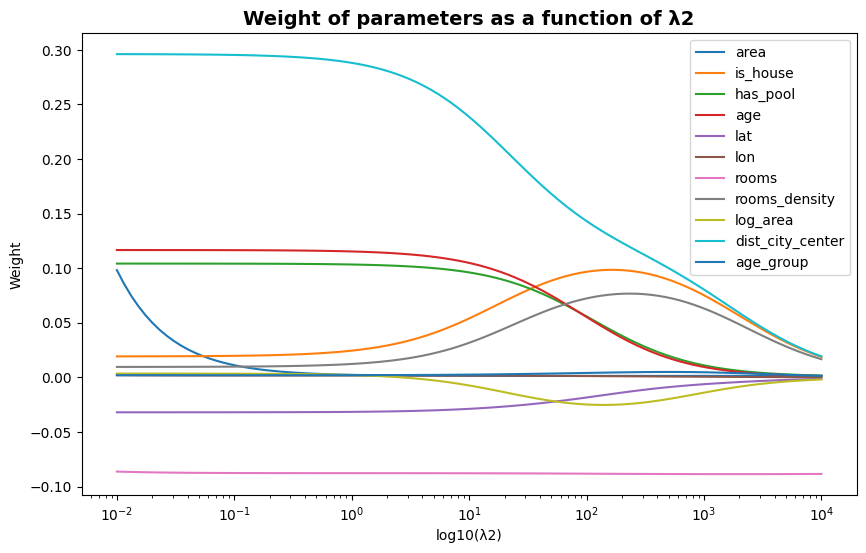


Best λ2: 0.01


,MSE,RMSE,MAE,R²
Train,4738.97,68.84,36.16,0.96


,MSE,RMSE,MAE,R²
Validation,4802.98,69.30,34.54,0.96



Model coefficients:
------------------------------
area                 | 0.09824
is_house             | 0.01923
has_pool             | 0.10424
age                  | 0.11663
lat                  | -0.03199
lon                  | 0.00197
rooms                | -0.08628
rooms_density        | 0.00957
log_area             | 0.00350
dist_city_center     | 0.29608
age_group            | 0.00198
------------------------------


In [17]:
lambdas_l2 = np.logspace(-2, 4, 100)
weights = []
best_lambda_dos = 0
best_r_dos = 0
for lamb in lambdas_l2:
    model_Fe.train_pseudo_inverse_regularized(l2=lamb)
    weights.append(model_Fe.coef)
    y_pred_train_Fe = model_Fe.predict(X_train_Fe)
    current_r_dos = r_dos(y_train_Fe, y_pred_train_Fe)
    if current_r_dos > best_r_dos:
        best_r_dos = current_r_dos
        best_lambda_dos = lamb

weights = np.array(weights)
plt.figure(figsize=(10, 6))
for i in range (len(features_Fe)):
    plt.plot(lambdas_l2, weights[:, i], label=f'{features_Fe[i]}')
plt.xlabel("log10(λ2)")
plt.ylabel("Weight")
plt.xscale("log")
plt.legend()
plt.title("Weight of parameters as a function of λ2", fontsize=14, weight='bold')
plt.show()

print(f"\nBest λ2: {best_lambda_dos}")
model_Fe.train_pseudo_inverse_regularized(l2=best_lambda_dos)
evaluate_model_performance(X_train_Fe, y_train_Fe, model_Fe, target_modified=1)
evaluate_model_performance(X_validation_Fe, y_validation_Fe, model_Fe, set='Validation', target_modified=1)
model_Fe.print_coef(features_Fe)

In this case, the parameter **$λ_2$** is varied from 0.01 to 10000, and the coefficients **$w^∗$** are plotted for each value of **$λ_2$**. The plot shows how the coefficients change as the regularization strength increases. As **$λ_2$** grows, the coefficients tend to zero, which is the expected behavior of L2 regularization. This regularization technique helps prevent overfitting by penalizing large coefficients, which can lead to model instability. To find a good value for **$λ_2$**, several models were trained with different lambda values ​​and the one that maximized the $R^2$ in the train set was chosen.

# 5.3
Realice el mismo gráfico del ítem anterior pero ahora utilizando regularización L1 (a veces llamado “LASSO regression”). Recuerde que no hay una solución analítica para w∗ con regularización L1, por lo cual solo será posible entrenar el modelo mediante gradiente descendiente. Analice el gráfico obtenido y compárelo con el anterior. ¿Qué conclusiones se pueden extraer en cuanto al efecto de utilizar regularización L1 vs. L2?

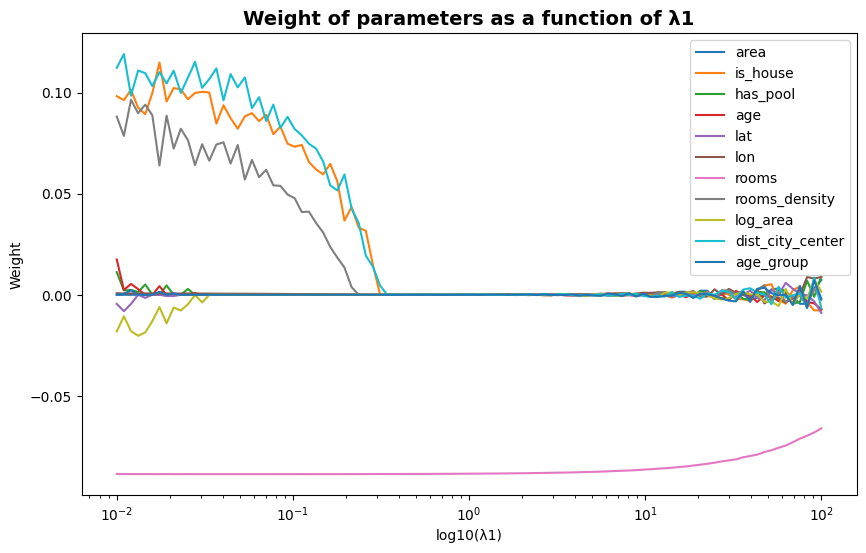


Best λ1: 0.01


,MSE,RMSE,MAE,R²
Train,7143.68,84.52,46.31,0.94


,MSE,RMSE,MAE,R²
Validation,5922.71,76.96,45.37,0.95



Model coefficients:
------------------------------
area                 | 0.00000
is_house             | 0.09576
has_pool             | 0.00649
age                  | 0.00885
lat                  | -0.00310
lon                  | 0.00075
rooms                | -0.08867
rooms_density        | 0.07874
log_area             | -0.01845
dist_city_center     | 0.12389
age_group            | 0.00000
------------------------------


In [ ]:
lambdas_l1 = np.logspace(-2, 2, 100)
weights = []
best_lambda_one = 0
best_r_dos = 0
for lamb in lambdas_l1:
    model_Fe.train_gradient_descent_lasso(l1=lamb)
    weights.append(model_Fe.coef)
    y_pred_train_Fe = model_Fe.predict(X_train_Fe)
    current_r_dos = r_dos(y_train_Fe, y_pred_train_Fe)
    if current_r_dos > best_r_dos:
        best_r_dos = current_r_dos
        best_lambda_one = lamb

weights = np.array(weights)
plt.figure(figsize=(10, 6))
for i in range (len(features_Fe)):
    plt.plot(lambdas_l1, weights[:, i], label=f'{features_Fe[i]}')
plt.xlabel("log10(λ1)")
plt.ylabel("Weight")
plt.xscale("log")
plt.legend()
plt.title("Weight of parameters as a function of λ1", fontsize=14, weight='bold')
plt.show()

print(f"\nBest λ1: {best_lambda_one}")
model_Fe.train_gradient_descent_lasso(l1=best_lambda_one)
evaluate_model_performance(X_train_Fe, y_train_Fe, model_Fe, target_modified=1)
evaluate_model_performance(X_validation_Fe, y_validation_Fe, model_Fe, set='Validation', target_modified=1)
model_Fe.print_coef(features_Fe)

In the resulting graph, it can be seen that many coefficients remain at small values, and some become exactly zero. This is because L1 performs feature selection, eliminating those that do not provide relevant information for property price prediction. This selection is called "sparsity." On the other hand, L2 does not eliminate features, but rather reduces their magnitude. Specifically, between $10^{-2}$ and $10^{-0.5}$ on the x-axis, the coefficients exhibit significant variability and appear to be unregularized. This is because $λ_1$ is small, implying that the L1 penalty is weak and the coefficients can take any value. From $10^{-0.5}$ to $10^{1}$, most coefficients tend toward small values ​​or zero. Finally, from $10^{1}$ to $10^{2}$, the coefficients exhibit significant variations, with some growing explosively. This suggests that excessively high regularization values can lead to instability in the model, causing extreme fluctuations in the learned coefficients.

On the other hand, in the first graph, as $log_{10}(λ_2)$ increases, the coefficients tend to decrease, but steadily, without becoming exactly zero. This occurs because L2 regularization penalizes large coefficients, but does not force them to exactly zero; instead, it gradually makes them smaller.

Therefore, it can be concluded that L1 is more aggressive in feature selection, as it can force some coefficients to zero, effectively removing them from the model or causing large variations. In contrast, L2 reduces the magnitude of the coefficients without eliminating them, leading to a smoother but non-sparse solution.

# 5.4
Ajuste el modelo de regresión del item (4.2) utilizando regularización L2 con coeficiente de regularización λ elegido de manera fundamentada, tomando como referencia lo graficado en el punto (5.2). ¿Cuál es el ECM obtenido en el conjunto de validación (y_val)? Explique en qué beneficia al modelo la regularización L2.

In [ ]:
model_Fe.train_pseudo_inverse_regularized(l2=best_lambda_dos)
y_amanda_predict_Fe = model_Fe.predict(X_amanda_Fe)
print(f"\nAmanda's house price: ${np.exp( y_amanda_predict_Fe[0] ):.2f}")

evaluate_model_performance(X_train_Fe, y_train_Fe, model_Fe, target_modified=1)
evaluate_model_performance(X_validation_Fe, y_validation_Fe, model_Fe, set='validation', target_modified=1)
model_Fe.print_coef(features_Fe)


Amanda's house price: $808.74


,MSE,RMSE,MAE,R²
Train,4738.97,68.84,36.16,0.96


,MSE,RMSE,MAE,R²
Validation,4802.98,69.30,34.54,0.96



Model coefficients:
------------------------------
area                 | 0.09824
is_house             | 0.01923
has_pool             | 0.10424
age                  | 0.11663
lat                  | -0.03199
lon                  | 0.00197
rooms                | -0.08628
rooms_density        | 0.00957
log_area             | 0.00350
dist_city_center     | 0.29608
age_group            | 0.00198
------------------------------


The optimal regularization coefficient $λ_2$ for L2 is 0.01, as it maximizes the **$R^2$** on the train set. This indicates that this value achieves an optimal balance between bias and variance, allowing for a good model fit without overfitting or underfitting.

Graphically, it can be seen that for small values ​​of $λ$, the coefficients have larger values, indicating that the model fits the data better, but with a risk of overfitting. On the other hand, for large values ​​of $λ$, the coefficients tend toward 0, indicating that the regularization is too strong and the model loses predictive power, with a risk of underfitting. Therefore, the value of $λ_2 = 0.01$ is considered optimal, as it maintains significant coefficient values ​​without forcing them to zero, ensuring that the model captures the structure of the data without excessive regularization.

With the regularization coefficient selected, the regression model was fitted and evaluated on the validation set, obtaining an **MSE of 4802.98**. L2 regularization benefits the model by reducing the magnitude of the coefficients, preventing overfitting and improving model generalization. In turn, it penalizes large coefficients, which prevents the model from overfitting to the training data, allowing it to better predict new data. This is evidenced by the coefficient corresponding to the variable **'area'**, where the coefficient without regularization is 7.779 and with regularization it is 0.0982. This fit demonstrates how regularization contributes to reducing the model's variance, stabilizing the coefficients without losing their impact on prediction.

# 5.5
En el ítem anterior se eligió el coeficiente de regularización λ aleatoriamente. Ahora determine su valor mediante un barrido del hiperparámetro y observando la variación del ECM evaluado sobre el conjunto de validación. ¿Se logró mejorar el ECM de validación?

In [20]:
weights = []
best_lambda_dos_val = 0
best_mse = np.inf
for lamb in lambdas_l2:
    model_Fe.train_pseudo_inverse_regularized(l2=lamb)
    weights.append(model_Fe.coef)
    y_pred_val_Fe = model_Fe.predict(X_validation_Fe)
    current_mse = mse(y_validation_Fe, y_pred_val_Fe)
    if current_mse < best_mse:
        best_mse = current_mse
        best_lambda_dos_val = lamb

print(f"\nBest λ2: {best_lambda_dos_val}")
model_Fe.train_pseudo_inverse_regularized(l2=best_lambda_dos_val)
evaluate_model_performance(X_validation_Fe, y_validation_Fe, model_Fe, set='validation', target_modified=1)


Best λ2: 4.641588833612782


,MSE,RMSE,MAE,R²
Validation,4754.29,68.95,34.76,0.96


In the previous item, the regularization coefficient $λ_2$ was chosen in a reasoned manner, seeking the optimum that maximizes the $R^2$ on the train set, having an MSE of 4802.98. On the other hand, when determining it by sweeping the hyperparameter, seeking to minimize the MSE on the validation set, a value of $λ_2$ = 4.64 was obtained, resulting in a better MSE of 4754.29.

It is entirely possible to obtain very different $λ_2$ values ​​when using **MSE** in validation and **$R^2$** in training, due to several reasons:

1. **Different evaluation metric**:
- $R^2$ measures the proportion of explained variance and does not penalize large individual errors as much as the MSE.
- The MSE minimizes large errors by squaring them, favoring larger $λ_2$ values ​​to avoid overfitting.

2. **Evaluation on different sets**:
- In the first case, the optimal value $λ_2 = 0.01$ was selected using $R^2$ on the training set, favoring a model that better fits these data.
- In the second case, the best $λ_2 = 4.64$ was obtained with the MSE in validation, suggesting that further regularization helped improve the model's generalization.

Therefore, the results obtained are not erroneous, but rather reflect the effect of:
- Using different metrics ($R^2$ vs. MSE).
- Evaluating on different sets (training vs. validation).

# 5.6
Repita el procedimiento del ítem anterior para elegir el valor del coeficiente de regularización λ, pero ahora evalue el ECM mediante validación cruzada. Grafique la variación del ECM vs. el valor del coeficiente de regularizacion.


Best λ2 found by cross-validation: 0.06892612104349695


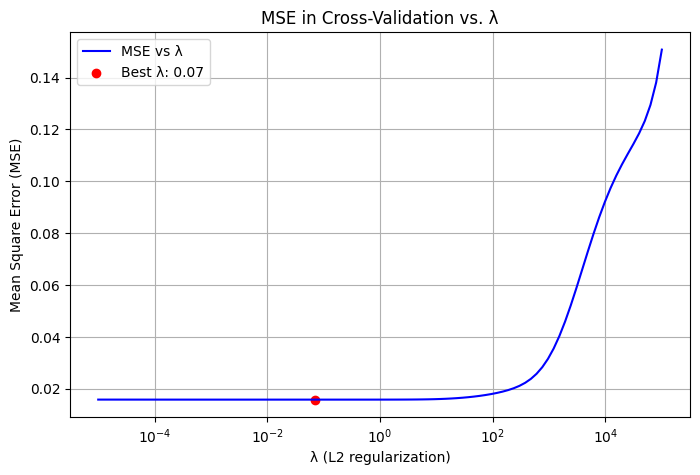

In [25]:
lambdas = np.logspace(-5, 5, 100)
best_lambda_cv, mse_values_cv = cross_val(X_train_Fe, y_train_Fe, LinearRegression, lambdas, k=300)
print(f"\nBest λ2 found by cross-validation: {best_lambda_cv}")

plt.figure(figsize=(8,5))
plt.plot(lambdas, mse_values_cv, linestyle='-', label="MSE vs λ", color='blue')
plt.scatter(best_lambda_cv, min(mse_values_cv), color='red', label=f"Best λ: {best_lambda_cv:.2f}")
plt.xscale("log")
plt.xlabel("λ (L2 regularization)")
plt.ylabel("Mean Square Error (MSE)")
plt.title("MSE in Cross-Validation vs. λ")
plt.legend()
plt.grid()
plt.show()

The graph shows the variation in the **Mean Square Error (MSE)** as a function of the regularization coefficient **$ \lambda $** in a regression with L2 regularization.

**For small values ​​of $ \lambda $ ($ 10^{-4} $ to $ 10^2 $)**
- The MSE is practically constant and low.
- Regularization has little impact, and the model fits the data well.

**For medium values ​​of $ \lambda $ (around $10^2$)**
- The MSE remains stable, indicating that the model is not yet being significantly penalized.

**For large values ​​of $ \lambda $ ($ 10^3 $ to $ 10^5 $)**
- The MSE begins to grow rapidly.
- Excessive regularization imposes strong restrictions on the coefficients, preventing the model from fitting the data well (overfitting).

Therefore, we can conclude that:
For low values ​​of $ \lambda $, the model fits well and the MSE is low.
For high values ​​of $ \lambda $, the model suffers from **underfitting** and the MSE increases because a large $λ$ imposes a severe penalty on the model's coefficients, reducing their magnitude and even bringing them closer to zero. This limits the model's ability to learn patterns in the data, making predictions overly simplistic and poorly tailored to reality. As a result, the validation error (MSE) is high because the model does not adequately capture the relationship between variables.

**There is an optimal point for $ \lambda $** where the MSE is minimal, this value is $\lambda _2 = 0.0689$.


# Selección de Modelo y Evaluación de Capacidad Predictiva

# 6.1
De todos los modelos realizados hasta ahora, ¿cuál seleccionaría para implementar en producción? Justifique su respuesta.

Of all the models evaluated, I would select the one developed in point (4.3) for production implementation. This model generated 300 new features from powers of the features obtained through feature engineering.

This model best fits the data, as generating new features provides more information to the model, allowing it to capture more complex relationships and improve predictive capacity. By having a greater amount of relevant information, the model becomes more expressive and accurate in predicting property prices.

Furthermore, this model obtained the best evaluation metrics, which supports its selection for production. Its performance can be seen in the Predicted vs. True Price graph, where the points are aligned close to the 45-degree line. This indicates that the model's predictions are well adjusted to actual values, reflecting robust and accurate performance.

,MSE,RMSE,MAE,R²
Train,3545.05,59.54,29.66,0.97


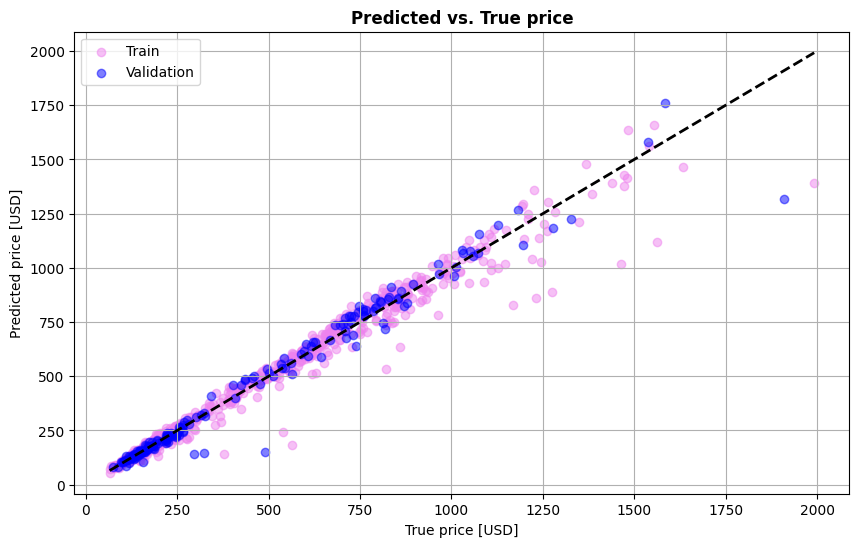

In [ ]:
evaluate_model_performance(X_train_300, y_train_300, model_300, target_modified=1)
model_300.plot_model_performance(X_train_300, y_train_300, X_validation_300, y_validation_300, target_log)

# 6.2
Para evaluar la capacidad predictiva del modelo seleccionado, compute y reporte el MAE (Mean Average Error ) y RMSE (Root Mean Squared Error ) sobre el conjunto de prueba.

In [30]:
df_test = pd.read_csv('../data/raw/casas_test.csv')

handle_missing_values(df_test, train_age_mean, train_age_std, train_rooms_mean, train_rooms_std, seed)
df_test = convert_sqft_to_m2(df_test)

df_test_copy = df_test.copy()
df_test_copy = apply_feature(df_test_copy, 'rooms_density', dependence(train_df, 'rooms_density', rooms_density), rooms_density)
df_test_copy = apply_feature(df_test_copy, 'log_price', dependence(train_df, 'log_price', log_price), log_price)
df_test_copy = apply_feature(df_test_copy, 'log_area', dependence(train_df, 'log_area', log_area), log_area)
df_test_copy = apply_feature(df_test_copy, 'dist_city_center', dependence(train_df, 'dist_city_center', dist_city_center), dist_city_center)
df_test_copy = apply_feature(df_test_copy, 'age_group', dependence(train_df, 'age_group', apply_age_group), apply_age_group)

test_300,_ = generate_features(df_test_copy, selected_combinations)
test_normalized_300 = normalize_data(test_300, train_mean_300, train_std_300, columns_to_not_normalize_Fe)
X_test_Fe, y_test_Fe = prepare_data(test_normalized_300, features_300, target_log)

evaluate_model_performance(X_test_Fe, y_test_Fe, model_300, set='test', target_modified=1)


**Correlations of rooms_density with other variables:**



,Variable,Correlation
0,rooms,0.351307
1,area,0.099230
2,lon,0.075404
3,lat,0.075382
4,is_house,0.029578
5,price,0.013458
6,age,0.012135
7,has_pool,0.010532



**Correlations of log_price with other variables:**



,Variable,Correlation
0,price,0.948674
1,lon,0.892319
2,lat,0.892224
3,is_house,0.371848
4,area,0.316360
5,rooms,0.307906
6,age,0.197213
7,has_pool,0.083017



**Correlations of log_area with other variables:**



...


**Correlations of dist_city_center with other variables:**



,Variable,Correlation
0,lat,0.073276
1,lon,0.071292
2,area,0.064850
3,rooms,0.051900
4,is_house,0.041537
5,age,0.037184
6,price,0.032376
7,has_pool,0.006919



**Correlations of age_group with other variables:**



,Variable,Correlation
0,age,0.868614
1,is_house,0.508361
2,lat,0.225926
3,lon,0.225876
4,price,0.179084
5,has_pool,0.086574
6,rooms,0.005661
7,area,0.000205


,MSE,RMSE,MAE,R²
Test,4777.65,69.12,34.62,0.95
